# Protein Sequence EDA

This notebook implements the phase-1 evidence gathering workflow for protein FASTA corpus profiling and pretraining-oriented analysis.


In [1]:
import os
import sys
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq

from IPython.display import display
from tqdm.auto import tqdm

from util.python.protein_fasta_io import parse_fasta_corpus
from util.python.file_utils import ensure_directories


In [2]:
REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_ROOT = REPO_ROOT / "data/raw/prot_only_dehydrated/ncbi_dataset/data"
OUTPUT_DIR = REPO_ROOT / "data/interim/protein_eda"
FIGURE_OUTPUT_DIR = REPO_ROOT / "results/protein_eda/figures"
ARTIFACT_OUTPUT_DIR = REPO_ROOT / "results/protein_eda/artifacts"
PARQUET_DATA_PATH = OUTPUT_DIR / "protein_corpus.parquet"

MAX_LENGTH = 512
PARSE_BATCH_SIZE = 4096
TOKENIZATION_STRATEGIES = ["single", "BPE"]
RARE_RESIDUE_POLICY = "replace_with_unk"  #  None
SAMPLE_MODE = None  # None  #500
# SAMPLE_MODE = 50  # None  #500
BPE_CANDIDATE_MODES = [1000, 4000, 8000]

SAVE_ARTIFACTS = True
SAVE_FIGURES = True

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [3]:
ensure_directories(ARTIFACT_OUTPUT_DIR, FIGURE_OUTPUT_DIR, OUTPUT_DIR)
if PARQUET_DATA_PATH.exists():
    PARQUET_DATA_PATH.unlink()

run_config = {
    "data_root": DATA_ROOT,
    "max_length": MAX_LENGTH,
    "batch_size": PARSE_BATCH_SIZE,
    "tokenization_strategies": TOKENIZATION_STRATEGIES,
    "rare_residue_policy": RARE_RESIDUE_POLICY,
    "sample_mode": SAMPLE_MODE,
    "bpe_candidate_modes": BPE_CANDIDATE_MODES,
    "artifact_output_dir": str(ARTIFACT_OUTPUT_DIR),
    "figure_output_dir": str(FIGURE_OUTPUT_DIR),
    "save_artifacts": SAVE_ARTIFACTS,
    "save_figures": SAVE_FIGURES,
}

display(pd.DataFrame([run_config]).T)

,0
data_root,/home/ubuntu/projects/biodata/DNA-BERT/data/raw/prot_only_dehydrated/ncbi_dataset/data
max_length,512
batch_size,4096
tokenization_strategies,"[single, BPE]"
rare_residue_policy,replace_with_unk
sample_mode,None
bpe_candidate_modes,"[1000, 4000, 8000]"
artifact_output_dir,/home/ubuntu/projects/biodata/DNA-BERT/results/protein_eda/artifacts
figure_output_dir,/home/ubuntu/projects/biodata/DNA-BERT/results/protein_eda/figures
save_artifacts,True


## Parse Corpus

Parse every available `protein.faa` file, preserve provenance, and surface malformed records or headers.


In [4]:
records_total_count = 0
issue_total_count = 0
parquet_writer = None

try:
    for records, issues in parse_fasta_corpus(DATA_ROOT, SAMPLE_MODE):
        if issues:
            issue_total_count += len(issues)
            print("Sample issues:")
            for issue in issues[:5]:
                print(f" - {issue}")

        if not records:
            continue

        batch_rows = []
        for record in records:
            row = record.to_dict()
            row.pop("issue", None)
            batch_rows.append(row)

        batch_table = pa.Table.from_pylist(batch_rows)

        if parquet_writer is None:
            parquet_writer = pq.ParquetWriter(
                str(PARQUET_DATA_PATH),
                batch_table.schema,
                compression="zstd",
            )

        parquet_writer.write_table(
            batch_table,
            row_group_size=PARSE_BATCH_SIZE,
        )
        records_total_count += len(batch_rows)

finally:
    if parquet_writer is not None:
        parquet_writer.close()
        parquet_writer = None

if records_total_count == 0:
    raise RuntimeError("No records were parsed from FASTA corpus.")


Discovered 22141 FASTA files in /home/ubuntu/projects/biodata/DNA-BERT/data/raw/prot_only_dehydrated/ncbi_dataset/data


Parsing FASTA files:   0%|          | 0/22141 [00:00<?, ?it/s]

In [5]:
protein_dataset = ds.dataset(str(PARQUET_DATA_PATH), format="parquet")

dataset_schema = pd.DataFrame(
    {
        "column": protein_dataset.schema.names,
        "dtype": [str(t) for t in protein_dataset.schema.types],
    }
)

display(dataset_schema)
print(f"Parsed records: {records_total_count:,}")
print(f"Parse issues captured: {issue_total_count:,}")

,column,dtype
0,assembly_id,string
1,sequence_id,string
2,ambiguous_residues,string
3,functional_annotations,string
4,raw_header,string
5,sequence_length,int64
6,sequence,string


Parsed records: 88,497,376
Parse issues captured: 0


### Parse Corpus: Output Notes

- Parsed records: **88,497,376**
- Parse issues captured: **0**
- Dataset schema table displayed correctly for downstream scanning.

Interpretation: FASTA ingestion completed and produced a queryable records table with provenance fields.


In [6]:
if SAVE_ARTIFACTS:
    preview_df = protein_dataset.head(100).to_pandas()
    preview_df.to_csv(ARTIFACT_OUTPUT_DIR.parent / "protein_records.csv", index=False)
    display(preview_df.sample(2))

,assembly_id,sequence_id,ambiguous_residues,functional_annotations,raw_header,sequence_length,sequence
88,GCF_000005845.2,NP_414638.1,,UDP-3-O-acyl-N-acetylglucosamine deacetylase,NP_414638.1 UDP-3-O-acyl-N-acetylglucosamine deacetylase [Escherichia coli str. K-12 substr. MG1655],305,MIKQRTLKRIVQATGVGLHTGKKVTLTLRPAPANTGVIYRRTDLNPPVDFPADAKSVRDTMLCTCLVNEHDVRISTVEHLNAALAGLGIDNIVIEVNAPEIPIMDGSAAPFVYLLLDAGIDELNCAKKFVRIKETVRVEDGDKWAEFKPYNGFSLDFTIDFNHPAIDSSNQRYAMNFSADAFMRQISRARTFGFMRDIEYLQSRGLCLGGSFDCAIVVDDYRVLNEDGLRFEDEFVRHKMLDAIGDLFMCGHNIIGAFTAYKSGHALNNKLLQAVLAKQEAWEYVTFQDDAELPLAFKAPSAVLA
87,GCF_000005845.2,NP_414637.1,,cell division protein FtsZ,NP_414637.1 cell division protein FtsZ [Escherichia coli str. K-12 substr. MG1655],383,MFEPMELTNDAVIKVIGVGGGGGNAVEHMVRERIEGVEFFAVNTDAQALRKTAVGQTIQIGSGITKGLGAGANPEVGRNAADEDRDALRAALEGADMVFIAAGMGGGTGTGAAPVVAEVAKDLGILTVAVVTKPFNFEGKKRMAFAEQGITELSKHVDSLITIPNDKLLKVLGRGISLLDAFGAANDVLKGAVQGIAELITRPGLMNVDFADVRTVMSEMGYAMMGSGVASGEDRAEEAAEMAISSPLLEDIDLSGARGVLVNITAGFDLRLDEFETVGNTIRAFASDNATVVIGTSLDPDMNDELRVTVVATGIGMDKRPEITLVTNKQVQQPVMDRYQQHGMAPLTQEQKPVAKVVNDNAPQTAKEPDYLDIPAFLRKQAD


In [7]:
record_count = protein_dataset.count_rows()
column_names = protein_dataset.schema.names

print(f"Total rows: {record_count:,}")

# Compute null counts across the full dataset using Arrow batches.
null_counts = {column: 0 for column in column_names}
null_scanner = protein_dataset.scanner(columns=column_names, batch_size=PARSE_BATCH_SIZE, use_threads=True)
for batch in tqdm(null_scanner.to_batches(), desc="Counting nulls by column", leave=False):
    for column in column_names:
        null_counts[column] += batch.column(column).null_count

null_summary_df = pd.DataFrame(
    {
        "column": column_names,
        "dtype": [str(t) for t in protein_dataset.schema.types],
        "null_count": [int(null_counts[column]) for column in column_names],
    }
)
null_summary_df["non_null_count"] = record_count - null_summary_df["null_count"]
null_summary_df["null_fraction"] = (null_summary_df["null_count"] / record_count) if record_count else 0.0
display(null_summary_df.sort_values(["null_count"], ascending=[False]).reset_index(drop=True))


Total rows: 88,497,376


Counting nulls by column: 0it [00:00, ?it/s]

,column,dtype,null_count,non_null_count,null_fraction
0,assembly_id,string,0,88497376,0.0
1,sequence_id,string,0,88497376,0.0
2,ambiguous_residues,string,0,88497376,0.0
3,functional_annotations,string,0,88497376,0.0
4,raw_header,string,0,88497376,0.0
5,sequence_length,int64,0,88497376,0.0
6,sequence,string,0,88497376,0.0


### check Seq length distribution


Counting nulls by column: 0it [00:00, ?it/s]

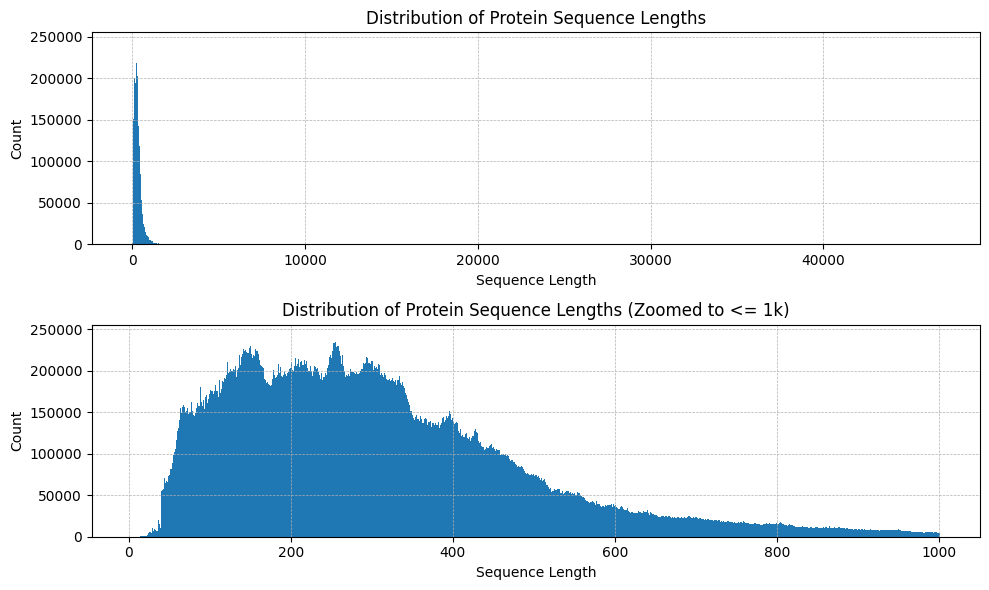

In [8]:
lengths = Counter()
scanner = protein_dataset.scanner(columns=column_names, batch_size=PARSE_BATCH_SIZE, use_threads=True)

for batch in tqdm(scanner.to_batches(), desc="Counting nulls by column", leave=False):
    for sequence_length in batch.column("sequence_length"):
        lengths[int(sequence_length)] += 1

# plot length distribution
lengths_df = pd.DataFrame({"sequence_length": list(lengths.keys()), "count": list(lengths.values())})
lengths_df = lengths_df.sort_values("sequence_length").reset_index(drop=True)


_lengths_df = lengths_df[lengths_df["sequence_length"] <= 1000]

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
ax[0].bar(lengths_df["sequence_length"], lengths_df["count"], width=1.0)
ax[0].set_title("Distribution of Protein Sequence Lengths")
ax[0].set_xlabel("Sequence Length")
ax[0].set_ylabel("Count")
ax[0].grid(True, which="both", linestyle="--", linewidth=0.5)


ax[1].bar(_lengths_df["sequence_length"], _lengths_df["count"], width=1.0)
ax[1].set_title("Distribution of Protein Sequence Lengths (Zoomed to <= 1k)")
ax[1].set_xlabel("Sequence Length")
ax[1].set_ylabel("Count")
ax[1].grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
# plt.xlim(0, 1000)
# plt.yscale("log")

if SAVE_FIGURES:
    plt.savefig(FIGURE_OUTPUT_DIR / "sequence_length_distribution_within_1k.png", dpi=300)
plt.show()
